In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import os
import cv2
import random
import numpy as np
from torch.amp import autocast, GradScaler
from PIL import Image
from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [2]:
ROOT_DIR = "/kaggle/input/datasets/nvquangai/img-caption/data_ready_for_kaggle"
TRAIN_PATH = os.path.join(ROOT_DIR, "cleaned_train.csv")
DEV_PATH = os.path.join(ROOT_DIR, "cleaned_dev.csv")
TEST_PATH = os.path.join(ROOT_DIR, "cleaned_test.csv")
IMAGES_DIR = os.path.join(ROOT_DIR, "images_resized")

BATCH_SIZE = 32
ACCUMULATION_STEPS = 2
EPOCHS = 15
LR_TEXT_DECODER = 3e-5
LR_VISION_LAYERS = 1e-6
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
LABEL_SMOOTHING = 0.1
MAX_LENGTH = 64
PATIENCE = 4
NUM_UNFREEZE_VISION_LAYERS = 2

SAVE_DIR = "./saved_models_v3"
PRINT_EVERY = 50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [3]:
train_augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1, hue=0.05),
])


class UITViICDataset(Dataset):
    def __init__(self, data_file, img_dir, processor, max_length=64,
                 mode='flat', augmentation=None):
        self.df = pd.read_csv(data_file)
        self.img_dir = img_dir
        self.processor = processor
        self.max_length = max_length
        self.mode = mode
        self.augmentation = augmentation

        if mode == 'grouped':
            self.image_groups = (
                self.df.groupby('image_file')['caption']
                .apply(list)
                .reset_index()
            )

    def __len__(self):
        if self.mode == 'grouped':
            return len(self.image_groups)
        return len(self.df)

    def __getitem__(self, index):
        if self.mode == 'grouped':
            row = self.image_groups.iloc[index]
            image_file = row['image_file']
            caption = random.choice(row['caption'])
        else:
            image_file = self.df.iloc[index]['image_file']
            caption = self.df.iloc[index]['caption']

        image_path = os.path.join(self.img_dir, image_file)
        image = Image.open(image_path).convert('RGB')

        if self.augmentation is not None:
            image = self.augmentation(image)

        encoding = self.processor(
            images=image,
            text=caption,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )
        encoding = {k: v.squeeze(0) for k, v in encoding.items()}

        labels = encoding["input_ids"].clone()
        pad_token_id = self.processor.tokenizer.pad_token_id
        labels[labels == pad_token_id] = -100
        encoding["labels"] = labels

        encoding["image_file"] = image_file
        encoding["raw_caption"] = caption

        return encoding

In [4]:
from transformers import BlipProcessor, BlipForConditionalGeneration, AutoTokenizer

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

vi_tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
processor.tokenizer = vi_tokenizer
model.text_decoder.resize_token_embeddings(len(vi_tokenizer))

print("=== TRUOC KHI FIX ===")
print(f"  model bos_token_id: {model.config.text_config.bos_token_id}")
print(f"  model eos_token_id: {model.config.text_config.eos_token_id}")
print(f"  model pad_token_id: {model.config.text_config.pad_token_id}")
print(f"  PhoBERT bos: {vi_tokenizer.bos_token_id}, eos: {vi_tokenizer.eos_token_id}, pad: {vi_tokenizer.pad_token_id}")
print()

model.config.text_config.bos_token_id = vi_tokenizer.bos_token_id
model.config.text_config.eos_token_id = vi_tokenizer.eos_token_id
model.config.text_config.pad_token_id = vi_tokenizer.pad_token_id
model.config.text_config.sep_token_id = vi_tokenizer.sep_token_id
model.config.text_config.vocab_size = len(vi_tokenizer)

model.generation_config.bos_token_id = vi_tokenizer.bos_token_id
model.generation_config.eos_token_id = vi_tokenizer.eos_token_id
model.generation_config.pad_token_id = vi_tokenizer.pad_token_id
model.generation_config.decoder_start_token_id = vi_tokenizer.bos_token_id

model.text_decoder.config.bos_token_id = vi_tokenizer.bos_token_id
model.text_decoder.config.eos_token_id = vi_tokenizer.eos_token_id
model.text_decoder.config.pad_token_id = vi_tokenizer.pad_token_id
model.text_decoder.config.sep_token_id = vi_tokenizer.sep_token_id
model.text_decoder.config.vocab_size = len(vi_tokenizer)

print("=== SAU KHI FIX ===")
print(f"  model bos_token_id: {model.config.text_config.bos_token_id}")
print(f"  model eos_token_id: {model.config.text_config.eos_token_id}")
print(f"  model pad_token_id: {model.config.text_config.pad_token_id}")
print(f"  generation bos: {model.generation_config.bos_token_id}, eos: {model.generation_config.eos_token_id}, pad: {model.generation_config.pad_token_id}")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
The new lm_head weights will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


=== TRUOC KHI FIX ===
  model bos_token_id: 30522
  model eos_token_id: 2
  model pad_token_id: 0
  PhoBERT bos: 0, eos: 2, pad: 1

=== SAU KHI FIX ===
  model bos_token_id: 0
  model eos_token_id: 2
  model pad_token_id: 1
  generation bos: 0, eos: 2, pad: 1


In [5]:
for param in model.vision_model.parameters():
    param.requires_grad = False

vision_layers = model.vision_model.encoder.layers
total_vision_layers = len(vision_layers)

for layer in vision_layers[-NUM_UNFREEZE_VISION_LAYERS:]:
    for param in layer.parameters():
        param.requires_grad = True

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
vision_trainable = sum(p.numel() for p in model.vision_model.parameters() if p.requires_grad)
text_trainable = sum(p.numel() for p in model.text_decoder.parameters() if p.requires_grad)

print(f"Total vision layers: {total_vision_layers}")
print(f"Unfrozen vision layers: {NUM_UNFREEZE_VISION_LAYERS}")
print(f"Total params:          {total_params:>12,}")
print(f"Trainable params:      {trainable_params:>12,}  ({trainable_params/total_params:.1%})")
print(f"  Vision (unfrozen):   {vision_trainable:>12,}")
print(f"  Text decoder:        {text_trainable:>12,}")

Total vision layers: 12
Unfrozen vision layers: 2
Total params:           249,715,457
Trainable params:       177,800,705  (71.2%)
  Vision (unfrozen):     14,175,744
  Text decoder:         163,624,961


In [6]:
train_dataset = UITViICDataset(
    data_file=TRAIN_PATH, img_dir=IMAGES_DIR, processor=processor,
    max_length=MAX_LENGTH, mode='grouped', augmentation=train_augmentation,
)

dev_dataset = UITViICDataset(
    data_file=DEV_PATH, img_dir=IMAGES_DIR, processor=processor,
    max_length=MAX_LENGTH, mode='flat', augmentation=None,
)

test_dataset = UITViICDataset(
    data_file=TEST_PATH, img_dir=IMAGES_DIR, processor=processor,
    max_length=MAX_LENGTH, mode='flat', augmentation=None,
)


def collate_fn(batch):
    tensor_keys = ['pixel_values', 'input_ids', 'attention_mask', 'labels']
    result = {}
    for key in tensor_keys:
        result[key] = torch.stack([item[key] for item in batch])
    result['image_file'] = [item['image_file'] for item in batch]
    result['raw_caption'] = [item['raw_caption'] for item in batch]
    return result


train_dataloader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=4, pin_memory=True, collate_fn=collate_fn,
)
dev_dataloader = DataLoader(
    dev_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=True, collate_fn=collate_fn,
)
test_dataloader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=True, collate_fn=collate_fn,
)

print(f"Train: {len(train_dataset)} samples (grouped, 1 random caption/epoch)")
print(f"Dev:   {len(dev_dataset)} samples")
print(f"Test:  {len(test_dataset)} samples")
print(f"Train batches/epoch: {len(train_dataloader)}")
print(f"Effective batch size: {BATCH_SIZE} x {ACCUMULATION_STEPS} = {BATCH_SIZE * ACCUMULATION_STEPS}")

Train: 9088 samples (grouped, 1 random caption/epoch)
Dev:   10002 samples
Test:  10001 samples
Train batches/epoch: 284
Effective batch size: 32 x 2 = 64


In [7]:
batch = next(iter(train_dataloader))
print("Keys:", [k for k in batch.keys()])
print("pixel_values:", batch['pixel_values'].shape)
print("input_ids:", batch['input_ids'].shape)
print("image_file:", batch['image_file'][0])
print("caption:", batch['raw_caption'][0])
print(f"pad_token_id: {processor.tokenizer.pad_token_id}")
print(f"bos_token_id: {model.generation_config.bos_token_id}")
print(f"eos_token_id: {model.generation_config.eos_token_id}")

Keys: ['pixel_values', 'input_ids', 'attention_mask', 'labels', 'image_file', 'raw_caption']
pixel_values: torch.Size([32, 3, 384, 384])
input_ids: torch.Size([32, 64])
image_file: 00000010812.jpg
caption: vài cô gái đang đi bộ dưới lòng đường cạnh vườn hoa
pad_token_id: 1
bos_token_id: 0
eos_token_id: 2


In [8]:
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup

optimizer_grouped_parameters = [
    {
        "params": [p for p in model.vision_model.parameters() if p.requires_grad],
        "lr": LR_VISION_LAYERS,
        "weight_decay": WEIGHT_DECAY,
    },
    {
        "params": [p for p in model.text_decoder.parameters() if p.requires_grad],
        "lr": LR_TEXT_DECODER,
        "weight_decay": WEIGHT_DECAY,
    },
]

optimizer = AdamW(optimizer_grouped_parameters)

steps_per_epoch = len(train_dataloader) // ACCUMULATION_STEPS
num_training_steps = steps_per_epoch * EPOCHS
num_warmup_steps = int(num_training_steps * WARMUP_RATIO)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
)

print(f"Steps/epoch: {steps_per_epoch}")
print(f"Total steps: {num_training_steps}")
print(f"Warmup steps: {num_warmup_steps}")

Steps/epoch: 142
Total steps: 2130
Warmup steps: 213


In [9]:
label_smoothing_loss = nn.CrossEntropyLoss(
    ignore_index=-100,
    label_smoothing=LABEL_SMOOTHING
)


def compute_loss_with_smoothing(model_output, labels):
    logits = model_output.logits
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = labels[:, 1:].contiguous()
    loss = label_smoothing_loss(
        shift_logits.view(-1, shift_logits.size(-1)),
        shift_labels.view(-1)
    )
    return loss

In [10]:
from tqdm import tqdm

os.makedirs(SAVE_DIR, exist_ok=True)

best_val_loss = float('inf')
patience_counter = 0
scaler = GradScaler()
train_losses = []
val_losses = []

print(f"Training start — {EPOCHS} epochs, effective batch={BATCH_SIZE*ACCUMULATION_STEPS}")
print(f"Label smoothing={LABEL_SMOOTHING}, patience={PATIENCE}")
print("=" * 70)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    model.train()
    running_loss = 0.0
    train_loss_total = 0.0
    optimizer.zero_grad()

    progress_bar = tqdm(
        enumerate(train_dataloader),
        total=len(train_dataloader),
        desc="Training"
    )

    for step, batch in progress_bar:
        pixel_values = batch['pixel_values'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        with autocast("cuda"):
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
            )
            loss = compute_loss_with_smoothing(outputs, labels)
            loss = loss / ACCUMULATION_STEPS

        scaler.scale(loss).backward()

        running_loss += loss.item() * ACCUMULATION_STEPS
        train_loss_total += loss.item() * ACCUMULATION_STEPS

        if (step + 1) % ACCUMULATION_STEPS == 0 or (step + 1) == len(train_dataloader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()

        if (step + 1) % PRINT_EVERY == 0:
            avg_loss = running_loss / PRINT_EVERY
            current_lr = scheduler.get_last_lr()[0]
            progress_bar.set_postfix({'loss': f"{avg_loss:.4f}", 'lr': f"{current_lr:.2e}"})
            running_loss = 0.0

    avg_train_loss = train_loss_total / len(train_dataloader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss_total = 0.0

    with torch.no_grad():
        for batch in tqdm(dev_dataloader, total=len(dev_dataloader), desc="Validating"):
            with autocast("cuda"):
                outputs = model(
                    pixel_values=batch['pixel_values'].to(device),
                    input_ids=batch['input_ids'].to(device),
                    attention_mask=batch['attention_mask'].to(device),
                    labels=batch['labels'].to(device),
                )
                val_loss = compute_loss_with_smoothing(outputs, batch['labels'].to(device))
            val_loss_total += val_loss.item()

    avg_val_loss = val_loss_total / len(dev_dataloader)
    val_losses.append(avg_val_loss)

    gap = avg_train_loss - avg_val_loss
    print(f"-> Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Gap: {gap:+.4f}")

    if avg_val_loss < best_val_loss:
        improvement = best_val_loss - avg_val_loss
        print(f"   Val loss improved {improvement:.4f} ({best_val_loss:.4f} -> {avg_val_loss:.4f}). Saving...")
        best_val_loss = avg_val_loss
        model.save_pretrained(SAVE_DIR)
        processor.save_pretrained(SAVE_DIR)
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"   No improvement. Patience: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print(f"   Early stopping at epoch {epoch+1}!")
            break

print(f"\nTraining done. Best val loss: {best_val_loss:.4f}")
print(f"Model saved at: {SAVE_DIR}")

Training start — 15 epochs, effective batch=64
Label smoothing=0.1, patience=4

Epoch 1/15


Validating: 100%|██████████| 313/313 [03:28<00:00,  1.50it/s]

-> Train Loss: 9.1899 | Val Loss: 6.9674 | Gap: +2.2225
   Val loss improved inf (inf -> 6.9674). Saving...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Epoch 2/15


...


Epoch 15/15


Validating: 100%|██████████| 313/313 [03:28<00:00,  1.50it/s]

-> Train Loss: 3.9085 | Val Loss: 4.0939 | Gap: -0.1854
   Val loss improved 0.0010 (4.0949 -> 4.0939). Saving...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training done. Best val loss: 4.0939
Model saved at: ./saved_models_v3


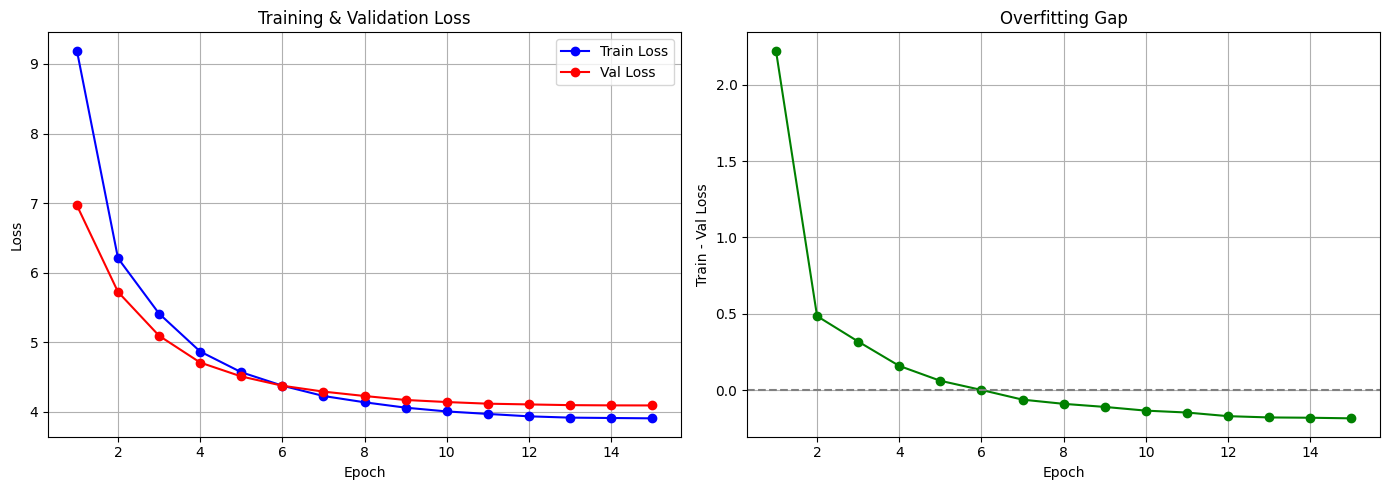

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(train_losses) + 1)

axes[0].plot(epochs_range, train_losses, 'b-o', label='Train Loss')
axes[0].plot(epochs_range, val_losses, 'r-o', label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True)

gaps = [t - v for t, v in zip(train_losses, val_losses)]
axes[1].plot(epochs_range, gaps, 'g-o')
axes[1].axhline(y=0, color='gray', linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Train - Val Loss')
axes[1].set_title('Overfitting Gap')
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150)
plt.show()

In [12]:
model = BlipForConditionalGeneration.from_pretrained(SAVE_DIR).to(device)
processor = BlipProcessor.from_pretrained(SAVE_DIR)
model.eval()

print(f"Loaded model from {SAVE_DIR}")
print(f"  bos_token_id: {model.generation_config.bos_token_id}")
print(f"  eos_token_id: {model.generation_config.eos_token_id}")
print(f"  pad_token_id: {model.generation_config.pad_token_id}")

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

Loaded model from ./saved_models_v3
  bos_token_id: 0
  eos_token_id: 2
  pad_token_id: 1


In [13]:
def generate_captions(model, processor, dataloader, device,
                      max_length=64, num_beams=5, no_repeat_ngram_size=3,
                      repetition_penalty=1.5):
    model.eval()
    results = {}

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Generating"):
            pixel_values = batch['pixel_values'].to(device)
            image_files = batch['image_file']

            generated_ids = model.generate(
                pixel_values=pixel_values,
                max_length=max_length,
                num_beams=num_beams,
                early_stopping=True,
                no_repeat_ngram_size=no_repeat_ngram_size,
                repetition_penalty=repetition_penalty,
            )

            preds = processor.batch_decode(generated_ids, skip_special_tokens=True)

            for img_file, pred in zip(image_files, preds):
                if img_file not in results:
                    results[img_file] = pred

    return results


test_predictions = generate_captions(model, processor, test_dataloader, device)
print(f"Generated {len(test_predictions)} captions")

Generating: 100%|██████████| 313/313 [24:35<00:00,  4.71s/it]

Generated 2001 captions


In [14]:
test_df = pd.read_csv(TEST_PATH)
sample_images = test_df['image_file'].unique()[:20]

for img_file in sample_images:
    pred = test_predictions.get(img_file, "N/A")
    refs = test_df[test_df['image_file'] == img_file]['caption'].tolist()
    print(f"\n{img_file}")
    print(f"  Pred: {pred}")
    print(f"  Ref:  {refs[0] if refs else 'N/A'}")


00000006091.jpg
  Pred: một tòa nhà màu vàng có nhiều cây xanh
  Ref:  một ngôi nhà màu vàng có các sợi dây leo màu xanh quấn xung quanh

00000006092.jpg
  Pred: một người đàn ông mặc áo màu trắng đang đứng trước một tòa nhà
  Ref:  một người đàn ông mặc áo màu trắng đeo cặp màu đen đang cúi đầu xuống

00000006093.png
  Pred: một người đàn ông đeo khẩu trang mặc áo sơ mi trắng đang đứng trước một chiếc xe máy
  Ref:  một người đàn ông mặc áo khoác màu xanh lá đang nhìn một người đàn ông mặc áo khoác màu xanh lá

00000006094.jpg
  Pred: một tòa nhà màu vàng có mái màu xanh lá
  Ref:  một toà nhà hình tròn màu xanh nước biển nằm ở giữa một bãi đất trống

00000006095.jpg
  Pred: một cửa hàng có biển hiệu màu vàng và chữ màu trắng
  Ref:  một cửa hàng tối đèn có biển hiệu phát sáng chữ nhiều màu

00000006096.jpg
  Pred: một người phụ nữ mặc áo màu trắng đang ngồi trên thuyền
  Ref:  một người phụ nữ áo đỏ đang đặt tay bên một thúng nhãn nằm gần các thúng nhẵn khác

00000006097.jpg
  Pred:

In [16]:
!pip install evaluate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


In [17]:
import evaluate


def build_multi_references(df):
    return df.groupby('image_file')['caption'].apply(list).to_dict()


def calculate_metrics(predictions_dict, references_dict):
    common_images = sorted(set(predictions_dict.keys()) & set(references_dict.keys()))
    predictions = [predictions_dict[img] for img in common_images]
    references = [references_dict[img] for img in common_images]

    print(f"Evaluating on {len(common_images)} images")
    print(f"Refs/image: {sum(len(r) for r in references) / len(references):.1f}")

    bleu_metric = evaluate.load("bleu")
    bleu_results = bleu_metric.compute(predictions=predictions, references=references)

    rouge_metric = evaluate.load("rouge")
    rouge_results = rouge_metric.compute(predictions=predictions, references=references)

    meteor_metric = evaluate.load("meteor")
    meteor_results = meteor_metric.compute(predictions=predictions, references=references)

    print(f"\nBLEU-1 : {bleu_results['precisions'][0] * 100:.2f}")
    print(f"BLEU-2 : {bleu_results['precisions'][1] * 100:.2f}")
    print(f"BLEU-3 : {bleu_results['precisions'][2] * 100:.2f}")
    print(f"BLEU-4 : {bleu_results['bleu'] * 100:.2f}")
    print(f"ROUGE-L: {rouge_results['rougeL'] * 100:.2f}")
    print(f"METEOR : {meteor_results['meteor'] * 100:.2f}")

    return {"bleu": bleu_results, "rouge": rouge_results, "meteor": meteor_results}

In [18]:
test_df = pd.read_csv(TEST_PATH)
test_references = build_multi_references(test_df)
metrics = calculate_metrics(test_predictions, test_references)

Evaluating on 2001 images
Refs/image: 5.0


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...



BLEU-1 : 75.80
BLEU-2 : 46.19
BLEU-3 : 26.42
BLEU-4 : 33.61
ROUGE-L: 53.33
METEOR : 40.11


In [19]:
comparison = pd.DataFrame({
    'Metric': ['BLEU-4', 'ROUGE-L', 'METEOR'],
    'v2': [6.18, 34.21, 34.62],
    'v3': [
        metrics['bleu']['bleu'] * 100,
        metrics['rouge']['rougeL'] * 100,
        metrics['meteor']['meteor'] * 100,
    ]
})
comparison['Delta'] = comparison['v3'] - comparison['v2']
print(comparison.to_string(index=False))

 Metric    v2        v3     Delta
 BLEU-4  6.18 33.606543 27.426543
ROUGE-L 34.21 53.334274 19.124274
 METEOR 34.62 40.108835  5.488835


In [20]:
import shutil

shutil.make_archive(
    '/kaggle/working/saved_models_v3',
    'zip',
    '/kaggle/working/'
)

'/kaggle/working/saved_models_v3.zip'